In [1]:
import polars as pl
import duckdb
import numpy as np

conn = duckdb.connect()


In [ ]:
df = pl.read_parquet("../data/faculty-salaries.parquet")


### Origional Data Shape

In [3]:
df.count()

name,job,department,base,overtime,other,notes,totalpay,totalbenefits,totalpaybenefits,year
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
5322827,5322827,0,5322827,5322827,5322827,28458,5322827,5322827,5322827,5322827


In [4]:
df.describe()

statistic,name,job,department,base,overtime,other,notes,totalpay,totalbenefits,totalpaybenefits,year
str,str,str,str,f64,f64,f64,str,f64,f64,f64,f64
"""count""","""5322827""","""5322827""","""0""",5.322827e6,5.322827e6,5.322827e6,"""28458""",5.322827e6,5.322827e6,5.322827e6,5.322827e6
"""null_count""","""0""","""0""","""5322827""",0.0,0.0,0.0,"""5294369""",0.0,0.0,0.0,0.0
"""mean""",null,null,null,45063.35434,690.482426,6142.070963,null,51895.964131,11449.320065,63345.335984,2017.894643
"""std""",null,null,null,51728.851627,3523.786051,33525.25106,null,71000.340768,15721.030227,82264.635075,4.030192
"""min""",""" judiyaba""",null,null,-385300.0,-49939.0,-345255.0,"""employee held multiple positio…",-331742.0,-95066.0,-331742.0,2011.0
"""25%""",null,null,null,3850.0,0.0,0.0,null,4709.0,0.0,4824.0,2014.0
"""50%""",null,null,null,29864.0,0.0,0.0,null,32376.0,0.0,37044.0,2018.0
"""75%""",null,null,null,67800.0,0.0,2383.0,null,72178.0,21722.0,93336.0,2021.0
"""max""","""ângela gomes tomaz""",null,null,1.965054e6,298933.0,6.761667e6,"""employee holds multiple positi…",7.061667e6,1.553747e6,7.110492e6,2024.0


### Data Cleanup
* Remove empty Cols
* Drop missing names and pays
* Base salary must be more than min wage
* Make all strings lowercase

In [5]:
# Drop empty cols: ual, benefitsee, benefitser, and benefitsdc
df = df.drop(['ual', 'benefitsee', 'benefitser', 'benefitsdc', 'notes'], strict=False)

# filter to base salary > 35152
df = df.filter(pl.col('totalpay') >= 35152)

df.count()


name,job,department,base,overtime,other,totalpay,totalbenefits,totalpaybenefits,year
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
2571751,2571751,0,2571751,2571751,2571751,2571751,2571751,2571751,2571751


* Since department data is missing (for now) we will be dropping that as well

In [6]:
df = df.drop(['department'], strict=False)

### Looking at *Educator* Jobs

In [7]:
duckdb.sql("""
    SELECT 
        job,
        COUNT(*) AS employee_count,
        ROUND(AVG(totalpaybenefits)) AS avg_pay
    FROM df
    WHERE 
        job ILIKE '%prof%'
        OR job ILIKE '%instr%'
        OR job ILIKE '%lect%'
        OR job ILIKE '%adj%'
    GROUP BY job
    ORDER BY employee_count DESC""").df()

,job,employee_count,avg_pay
0,instructional faculty - academic year,135427,130045.0
1,lecturer - academic year,73279,81683.0
2,prof-ay,43553,231072.0
3,hs asst clin prof-hcomp,21856,279020.0
4,assoc prof-ay,18618,151679.0
...,...,...,...
713,act prof-acad yr-bus/econ/eng,1,171275.0
714,lect w/sec-ay-recall-1/9th,1,39257.0
715,lect psoe-ay-1/9-100%,1,41464.0
716,"electrician, casual employment",1,69014.0


### Narrow the df to only educational faculty with totalpay >= 10k

In [8]:
df = duckdb.sql("""
    SELECT *
    FROM df
    WHERE 
        job ILIKE '%prof%'
        OR job ILIKE '%instruct%'
        OR job ILIKE '%faculty%'
        OR job ILIKE '%lectur%'
        OR job ILIKE '%adjunct%'
        AND totalpay >= 10000
        """).df()

In [9]:
duckdb.sql(""" 
    CREATE TABLE faculty_salaries AS
    SELECT *
    FROM df
""")

#### Investigating Faculty with a tenure of at lease 10 years 
First I want just faculty who've been around for 10 years and their pay

In [10]:
duckdb.sql("""
WITH yearly_pay AS (
    SELECT name, job, year, SUM(totalpay) AS pay
    FROM faculty_salaries
    GROUP BY name, job, year
),
oldtimers AS (
    -- Group for consecutive years
    SELECT name, job, year, pay,
        year - CAST(ROW_NUMBER() OVER (PARTITION BY name ORDER BY year) AS INT) AS grp
    FROM yearly_pay
),
valid_groups AS (
    -- People who have had 10 consecutive years of pay
    SELECT name, grp
    FROM oldtimers
    GROUP BY name, grp
    HAVING COUNT(*) >= 10
)
SELECT oldtimers.name, oldtimers.job, oldtimers.year, ROUND(oldtimers.pay) AS pay
FROM oldtimers
JOIN valid_groups 
    ON oldtimers.name = valid_groups.name 
    AND oldtimers.grp = valid_groups.grp
ORDER BY oldtimers.name, oldtimers.year
""").df()

,name,job,year,pay
0,a dee williams,instructional faculty - academic year,2011,68328.0
1,a dee williams,instructional faculty - academic year,2012,69228.0
2,a dee williams,instructional faculty - academic year,2013,67811.0
3,a dee williams,instructional faculty - academic year,2014,75698.0
4,a dee williams,instructional faculty - academic year,2015,80975.0
...,...,...,...,...
156067,zvonimir hlousek,instructional faculty - academic year,2016,112271.0
156068,zvonimir hlousek,instructional faculty - academic year,2017,101110.0
156069,zvonimir hlousek,instructional faculty - academic year,2018,102258.0
156070,zvonimir hlousek,instructional faculty - academic year,2019,107228.0


* Get faculty who have been around a long time get their starting pay and ending pay

In [17]:
pay_df = duckdb.sql("""
WITH yearly_pay AS (
    SELECT name, job, year, ANY_VALUE(totalpay) AS pay
    FROM faculty_salaries
    GROUP BY name, job, year
),
collision_check AS (
    SELECT name, job, year, pay,
        COUNT(*) OVER (PARTITION BY name, year) AS year_total
    FROM yearly_pay  
),
collision_purged AS (
    SELECT name, job, year, pay
    FROM collision_check
    WHERE year_total = 1
),
oldtimers AS (
    SELECT name, year, pay, job,
        year - CAST(ROW_NUMBER() OVER (PARTITION BY name ORDER BY year) AS INT) AS grp
    FROM collision_purged
),
consecutive_years AS (
    SELECT 
        name,
        MIN(year) AS start_year,
        MAX(year) AS end_year,
        MIN(job) AS starting_job,
        MAX(job) AS ending_job,
        
        arg_min(pay, year) AS starting_pay,
        arg_max(pay, year) AS ending_pay
    FROM oldtimers
    GROUP BY name, job, grp
    HAVING COUNT(*) >= 10
)
SELECT 
    name,
    starting_job,
    ending_job,
    start_year,
    end_year,
    starting_pay,
    ending_pay
    FROM consecutive_years
    ORDER BY ending_pay DESC
""").df()

pay_df

,name,starting_job,ending_job,start_year,end_year,starting_pay,ending_pay
0,abbas ardehali,prof-hcomp,prof-hcomp,2013,2024,1329568,2175436
1,akira ishiyama,prof-hcomp,prof-hcomp,2013,2024,650221,1694312
2,ehtisham mahmud,prof of clin-hcomp,prof of clin-hcomp,2013,2024,850216,1668650
3,rohit loomba,prof-hcomp,prof-hcomp,2015,2024,640436,1351040
4,geoffrey manley,prof in res-hcomp,prof in res-hcomp,2013,2024,538027,1294299
...,...,...,...,...,...,...,...
10043,jesse f battan,instructional faculty - academic year,instructional faculty - academic year,2014,2024,124227,35304
10044,rosalind c on,student services professional iii,student services professional iii,2011,2021,58267,35286
10045,laurice f mogannam,lecturer - academic year,lecturer - academic year,2011,2022,35275,35273
10046,patrick j surgalski,instructional faculty - academic year,instructional faculty - academic year,2011,2020,88044,35236


#### Median Difference Between Starting and Ending Pay

In [18]:
pay_df['pay_difference'] = pay_df['ending_pay'] - pay_df['starting_pay']

median_diff = pay_df['pay_difference'].median()
mean_diff = pay_df['pay_difference'].mean()

print(f"Median Pay Difference: ${median_diff:,.2f}")
print(f"Mean Pay Difference: ${mean_diff:,.2f}")
# Starting pay max and max Ending pay
print(f"Max Starting Pay: ${pay_df['starting_pay'].max():,.2f}")
print(f"Max Ending Pay: ${pay_df['ending_pay'].max():,.2f}")

Median Pay Difference: $46,908.00
Mean Pay Difference: $50,000.73
Max Starting Pay: $1,329,568.00
Max Ending Pay: $2,175,436.00


In [19]:
# Only include people whos ending pay is greater than starting pay
pay_df = pay_df[pay_df['ending_pay'] > pay_df['starting_pay']]


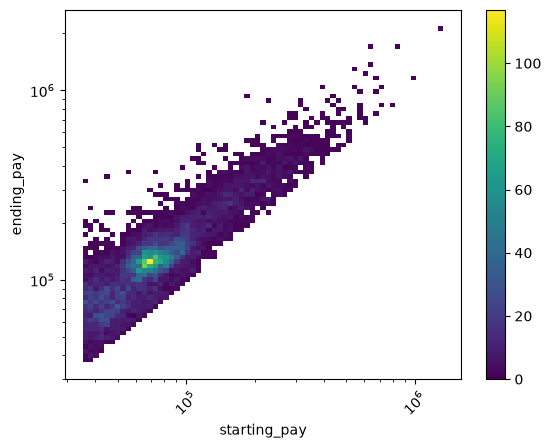

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=pay_df, x="starting_pay", y="ending_pay", cbar=True, cmap="viridis", 
             log_scale=(True, True))
plt.xticks(rotation=45)
plt.show()

Names are not unique... current solution, drop name collisions

### Overall Pay Stats

In [29]:
col = df["totalpay"]

col.mean()
col.median()                                       # center — robust
col.std()    
col.min()
col.max()                                        # spread — sensitive
print("Mean:", col.mean())
print("Median:", col.median())
print("Standard Deviation:", col.std())
print("Minimum:", col.min())
print("Maximum:", col.max())
print("IQR:", col.quantile(0.75) - col.quantile(0.25))

df.describe()


Mean: 145004.46355274064
Median: 103927.0
Standard Deviation: 128122.51305217456
Minimum: 35152
Maximum: 3974061
IQR: 108121.0


,base,overtime,other,totalpay,totalbenefits,totalpaybenefits,year
count,533346.00000,533346.000000,5.333460e+05,5.333460e+05,533346.000000,5.333460e+05,533346.000000
mean,106985.35767,19.692342,3.799929e+04,1.450045e+05,28909.831696,1.739145e+05,2018.118713
std,62611.32938,454.837009,8.930018e+04,1.281225e+05,18148.351516,1.352852e+05,4.002753
min,-385300.00000,-8585.000000,-3.452550e+05,3.515200e+04,-46556.000000,1.598100e+04,2011.000000
25%,61515.00000,0.000000,0.000000e+00,6.673700e+04,16883.000000,8.951300e+04,2015.000000
50%,94036.00000,0.000000,6.073000e+03,1.039270e+05,30295.500000,1.372160e+05,2018.000000
75%,134093.00000,0.000000,3.378300e+04,1.748580e+05,41501.000000,2.090470e+05,2022.000000
max,838117.00000,58109.000000,3.695451e+06,3.974061e+06,150650.000000,4.046492e+06,2024.000000
